# Neural Networks: The Basics
### Building a Simple Neural Network with PyTorch on the Diabetes Dataset

**Learning Goals Covered:**
- Understand what neurons, layers, weights, and training actually mean
- Set up PyTorch and run a complete end-to-end neural network
- Build a small neural network on the familiar Diabetes dataset (from Week 5/6)
- Compare performance with the traditional ML models from earlier weeks

---
## 🧩 Part 1: How Does a Neural Network Work? (Plain English)

Before writing any code, let's understand what we're building.

---

### 🔵 What is a Neuron?
A **neuron** is the simplest building block. It takes some numbers as input, multiplies each one by a **weight** (how important is this input?), adds them all up, and then passes the result through an **activation function** that decides whether and how strongly to "fire" a signal forward.

Think of it like this: imagine you're deciding whether to watch a movie. You weigh factors — rating (weight: 0.8), director (weight: 0.6), trailer (weight: 0.4). You add them up and if the total crosses a threshold, you go watch it. That's a neuron.

---

### 🔵 What is a Layer?
A **layer** is just a group of neurons sitting at the same depth in the network. Every neural network has:
- **Input Layer** — receives your raw data (one neuron per feature)
- **Hidden Layer(s)** — intermediate layers that learn patterns. The more layers, the more complex patterns the network can learn.
- **Output Layer** — produces the final prediction

Data flows left to right through all layers — this is called a **forward pass**.

---

### 🔵 What are Weights and How Does the Network Learn?
Every connection between two neurons has a **weight** — a number that controls how much influence one neuron has on the next.

When you first create a network, all weights are **random**. The network makes a terrible prediction. Then:
1. We measure how wrong the prediction was — this is the **Loss**
2. We work backwards through the network to figure out which weights caused the error — this is called **Backpropagation**
3. We nudge each weight slightly in the direction that reduces the error — this is called **Gradient Descent**
4. We repeat this thousands of times with different batches of data

Each complete pass through all your training data is called an **Epoch**. Over many epochs, the weights gradually settle into values that make good predictions.

---

### 🔵 What is an Activation Function?
Without an activation function, stacking multiple layers would be pointless — the whole network would just behave like a single straight line (linear function) no matter how deep it is.

Activation functions add **non-linearity**, which is what allows neural networks to learn complex, curved patterns in data. Common ones:
- **ReLU** (Rectified Linear Unit): `max(0, x)` — most common for hidden layers. Simple and effective.
- **Sigmoid**: squashes output between 0 and 1 — used for binary classification output
- **Linear** (no activation): used for regression output (we want any real number)

---

**Our network architecture for this notebook:**
```
Input (13 features)
     ↓
Hidden Layer 1 (64 neurons, ReLU)
     ↓
Hidden Layer 2 (32 neurons, ReLU)
     ↓
Hidden Layer 3 (16 neurons, ReLU)
     ↓
Output (1 neuron, Linear → predicts disease progression score)
```

---
## 📦 Part 2: Setup — Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# PyTorch — Deep Learning
import torch
import torch.nn as nn                          # neural network building blocks
import torch.optim as optim                    # optimizers (gradient descent)
from torch.utils.data import DataLoader, TensorDataset  # data loading utilities

# Sklearn — dataset and preprocessing
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# For Week 5/6 comparison
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check PyTorch version and device
print(f'PyTorch Version  : {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device           : {device}  (cuda = GPU, cpu = normal processor)')
print('\n✅ Setup complete — ready to build neural networks!')

PyTorch Version  : 2.12.1
Device           : cpu  (cuda = GPU, cpu = normal processor)

✅ Setup complete — ready to build neural networks!


---
## 📂 Part 3: Load & Prepare the Familiar Diabetes Dataset

We're using the same **Diabetes dataset** from Weeks 5/6 — so we already know it well.
- **442 samples**, **13 features** (age, BMI, blood pressure, etc.)
- **Task**: predict a continuous disease progression score (regression)

In [2]:
# Load the same dataset from Weeks 5/6
diabetes = load_diabetes()
X_raw = diabetes.data
y_raw = diabetes.target

df = pd.DataFrame(X_raw, columns=diabetes.feature_names)
df['target'] = y_raw

print('Dataset                 :', 'Diabetes (same as Week 5/6)')
print('Shape                   :', df.shape)
print('Features                :', list(diabetes.feature_names))
print('Target (predict)        : Disease progression score (continuous)')
print(f'Target range            : {y_raw.min():.0f} to {y_raw.max():.0f}')
df.head()

Dataset                 : Diabetes (same as Week 5/6)
Shape                   : (442, 11)
Features                : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (predict)        : Disease progression score (continuous)
Target range            : 25 to 346


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Step 1: Scale features (same as Week 6/7)
# Neural networks are very sensitive to feature scale —
# unscaled data causes slow training and poor convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 2: Train / Validation / Test split
# We use a 3-way split for neural networks:
#   Train (70%)     — model learns from this
#   Validation (15%)— we monitor this during training to detect overfitting
#   Test (15%)      — final evaluation, never seen during training
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 of 85% ≈ 15% of total
)

print(f'Training samples   : {len(X_train)}')
print(f'Validation samples : {len(X_val)}')
print(f'Test samples       : {len(X_test)}')

# Step 3: Convert numpy arrays → PyTorch tensors
# PyTorch works with its own data format called "tensors" (like numpy arrays but GPU-compatible)
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t = to_tensor(X_train)
y_train_t = to_tensor(y_train).unsqueeze(1)   # shape: (N,) → (N, 1) for output layer
X_val_t   = to_tensor(X_val)
y_val_t   = to_tensor(y_val).unsqueeze(1)
X_test_t  = to_tensor(X_test)
y_test_t  = to_tensor(y_test).unsqueeze(1)

# Step 4: Wrap in DataLoader — handles batching and shuffling automatically
# Batch size = 32: the network sees 32 samples at a time before updating weights
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f'\nTensor shapes:')
print(f'  X_train : {X_train_t.shape}  (samples × features)')
print(f'  y_train : {y_train_t.shape}  (samples × output)')
print('\n✅ Data ready for PyTorch!')

Training samples   : 309
Validation samples : 66
Test samples       : 67

Tensor shapes:
  X_train : torch.Size([309, 10])  (samples × features)
  y_train : torch.Size([309, 1])  (samples × output)

✅ Data ready for PyTorch!


---
## 🏗️ Part 4: Build the Neural Network

In PyTorch, we define a neural network as a **Python class** that:
1. Defines the layers in `__init__`
2. Defines how data flows through them in `forward`

In [4]:
class DiabetesNet(nn.Module):
    """
    A simple feed-forward neural network for predicting diabetes disease progression.
    
    Architecture:
        Input (13)  →  Hidden1 (64, ReLU)  →  Hidden2 (32, ReLU)
                    →  Hidden3 (16, ReLU)  →  Output (1, Linear)
    """
    def __init__(self, input_size=13):
        super(DiabetesNet, self).__init__()
        
        # nn.Sequential: layers are stacked in order — data passes through each one
        self.network = nn.Sequential(
            
            # Hidden Layer 1: 13 inputs → 64 neurons
            nn.Linear(input_size, 64),   # Linear = fully connected (every input connects to every neuron)
            nn.ReLU(),                   # Activation: max(0, x) — adds non-linearity
            nn.BatchNorm1d(64),          # Batch Normalization: stabilizes training
            nn.Dropout(0.2),             # Dropout: randomly turns off 20% of neurons to prevent overfitting
            
            # Hidden Layer 2: 64 → 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            
            # Hidden Layer 3: 32 → 16 neurons
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # Output Layer: 16 → 1 neuron (no activation = linear output for regression)
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        """Define the forward pass — how data flows through the network."""
        return self.network(x)


# Create the model and move to device (GPU if available, else CPU)
model = DiabetesNet(input_size=X_train.shape[1]).to(device)

print('Neural Network Architecture:')
print('=' * 52)
print(model)
print('=' * 52)

# Count total learnable parameters (weights + biases)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal Learnable Parameters: {total_params:,}')
print('(These are the weights the network will adjust during training)')

Neural Network Architecture:
DiabetesNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total Learnable Parameters: 3,521
(These are the weights the network will adjust during training)


---
## ⚙️ Part 5: Define Loss Function & Optimizer

Before training, we need two things:

- **Loss Function** — measures how wrong our predictions are. For regression (predicting a number), we use **Mean Squared Error (MSE)**.
- **Optimizer** — the algorithm that updates weights to reduce the loss. We use **Adam** — a modern, adaptive version of gradient descent that works well out of the box.

In [6]:
# Loss function: Mean Squared Error
# MSE = average of (prediction - actual)² across all samples
# The lower the MSE, the better our predictions
criterion = nn.MSELoss()

# Optimizer: Adam
# lr (learning rate) = how big a step we take when updating weights
# Too high = overshoots the minimum; Too low = trains very slowly
# 0.001 is a reliable default starting point
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning Rate Scheduler — reduces learning rate when validation loss stops improving
# This helps fine-tune the weights in the later stages of training
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=20, factor=0.5
)

print('Loss Function  : Mean Squared Error (MSE)')
print('               → Penalizes large prediction errors heavily')
print('Optimizer      : Adam (Adaptive Moment Estimation)')
print('               → Adapts learning rate per-weight automatically')
print('Learning Rate  : 0.001')
print('Scheduler      : ReduceLROnPlateau (halves LR if stuck for 20 epochs)')
print('Weight Decay   : 1e-4 (L2 regularization — prevents overfitting)')

Loss Function  : Mean Squared Error (MSE)
               → Penalizes large prediction errors heavily
Optimizer      : Adam (Adaptive Moment Estimation)
               → Adapts learning rate per-weight automatically
Learning Rate  : 0.001
Scheduler      : ReduceLROnPlateau (halves LR if stuck for 20 epochs)
Weight Decay   : 1e-4 (L2 regularization — prevents overfitting)


---
## 🏋️ Part 6: Train the Neural Network

The training loop repeats for each **epoch** (one full pass through the data):
1. **Forward Pass** — feed data through the network, get predictions
2. **Compute Loss** — measure how wrong the predictions are
3. **Backward Pass (Backprop)** — calculate how much each weight contributed to the error
4. **Update Weights** — nudge weights in the direction that reduces loss

In [7]:
# Training configuration
EPOCHS     = 300
train_losses = []
val_losses   = []
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
EARLY_STOP_PATIENCE = 50  # stop if val loss doesn't improve for 50 epochs

print(f'Training for up to {EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>12} | {"LR":>10}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    
    # ── TRAINING PHASE ──────────────────────────────────────
    model.train()   # sets model to training mode (enables Dropout, BatchNorm)
    epoch_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Step 1: Zero out gradients from last batch
        optimizer.zero_grad()
        
        # Step 2: Forward pass — get predictions
        predictions = model(X_batch)
        
        # Step 3: Compute loss
        loss = criterion(predictions, y_batch)
        
        # Step 4: Backward pass — compute gradients
        loss.backward()
        
        # Step 5: Update weights
        optimizer.step()
        
        epoch_train_loss += loss.item() * X_batch.size(0)
    
    epoch_train_loss /= len(train_loader.dataset)
    
    # ── VALIDATION PHASE ────────────────────────────────────
    model.eval()    # sets model to evaluation mode (disables Dropout, BatchNorm uses running stats)
    with torch.no_grad():   # no_grad: don't track gradients (saves memory, speeds up)
        val_preds = model(X_val_t.to(device))
        val_loss  = criterion(val_preds, y_val_t.to(device)).item()
    
    # Store losses
    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)
    
    # Learning rate scheduler step
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Print progress every 50 epochs
    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>6} | {epoch_train_loss:>12.2f} | {val_loss:>12.2f} | {current_lr:>10.6f}')
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\n⏹️  Early stopping at epoch {epoch} — val loss not improving.')
        break

# Restore best model weights
model.load_state_dict(best_model_state)
print(f'\n✅ Training complete! Best Validation Loss: {best_val_loss:.2f}')

Training for up to 300 epochs...

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
     1 |     29280.97 |     29904.08 |   0.001000
    50 |      4873.05 |      4582.81 |   0.001000
   100 |      3018.88 |      4244.33 |   0.000250

⏹️  Early stopping at epoch 107 — val loss not improving.

✅ Training complete! Best Validation Loss: 4061.16


---
## 📉 Part 7: Visualize Training — Loss Curves

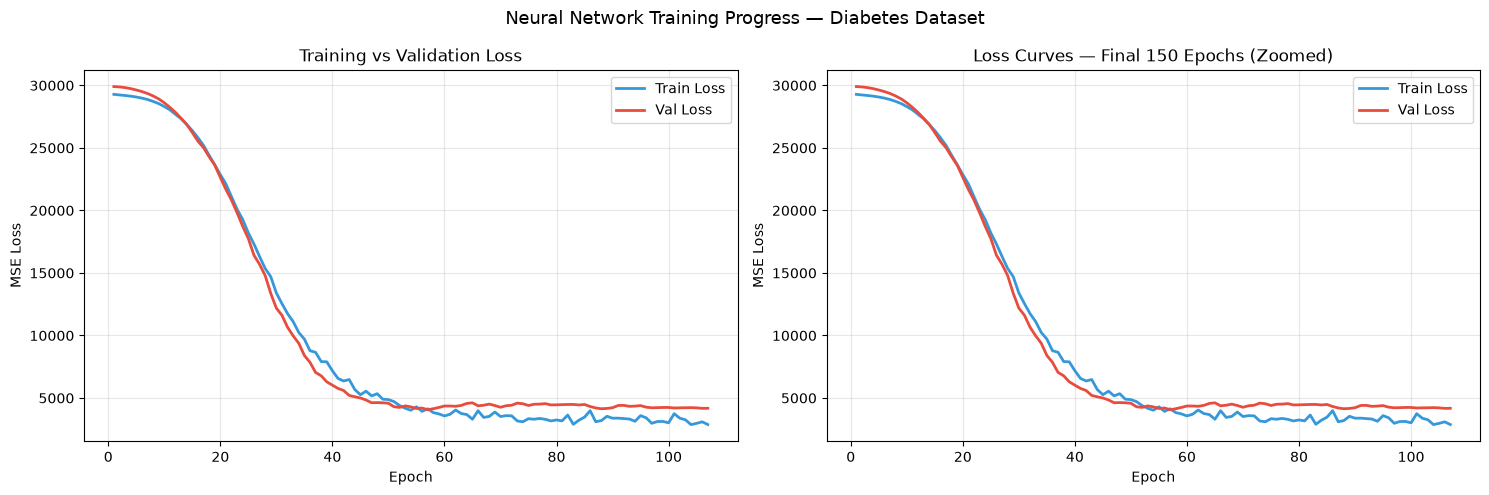

How to read the loss curves:
  • Both curves decreasing = network is learning ✅
  • Val loss >> Train loss = overfitting ⚠️
  • Both curves flat = converged ✅
  • Val loss increasing while train loss drops = clear overfitting 🚨


In [8]:
# Loss curves — the most important diagnostic tool for neural networks
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs_ran = len(train_losses)

# Full loss curve
axes[0].plot(range(1, epochs_ran + 1), train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(range(1, epochs_ran + 1), val_losses,   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed — last 150 epochs (shows convergence clearly)
zoom_start = max(0, epochs_ran - 150)
axes[1].plot(range(zoom_start + 1, epochs_ran + 1), train_losses[zoom_start:],
             label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(range(zoom_start + 1, epochs_ran + 1), val_losses[zoom_start:],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss Curves — Final 150 Epochs (Zoomed)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network Training Progress — Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print('How to read the loss curves:')
print('  • Both curves decreasing = network is learning ✅')
print('  • Val loss >> Train loss = overfitting ⚠️')
print('  • Both curves flat = converged ✅')
print('  • Val loss increasing while train loss drops = clear overfitting 🚨')

---
## 📊 Part 8: Evaluate on Test Set

In [9]:
# Final evaluation on the test set (never seen during training)
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_t.to(device))
    y_pred_np     = y_pred_tensor.cpu().numpy().flatten()
    y_test_np     = y_test

# Metrics
r2   = r2_score(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mae  = mean_absolute_error(y_test_np, y_pred_np)

print('=' * 45)
print('   Neural Network — Test Set Results')
print('=' * 45)
print(f'  R² Score  : {r2:.4f}   (1.0 = perfect)')
print(f'  RMSE      : {rmse:.4f}')
print(f'  MAE       : {mae:.4f}')
print('=' * 45)

   Neural Network — Test Set Results
  R² Score  : 0.0928   (1.0 = perfect)
  RMSE      : 70.3960
  MAE       : 51.1035


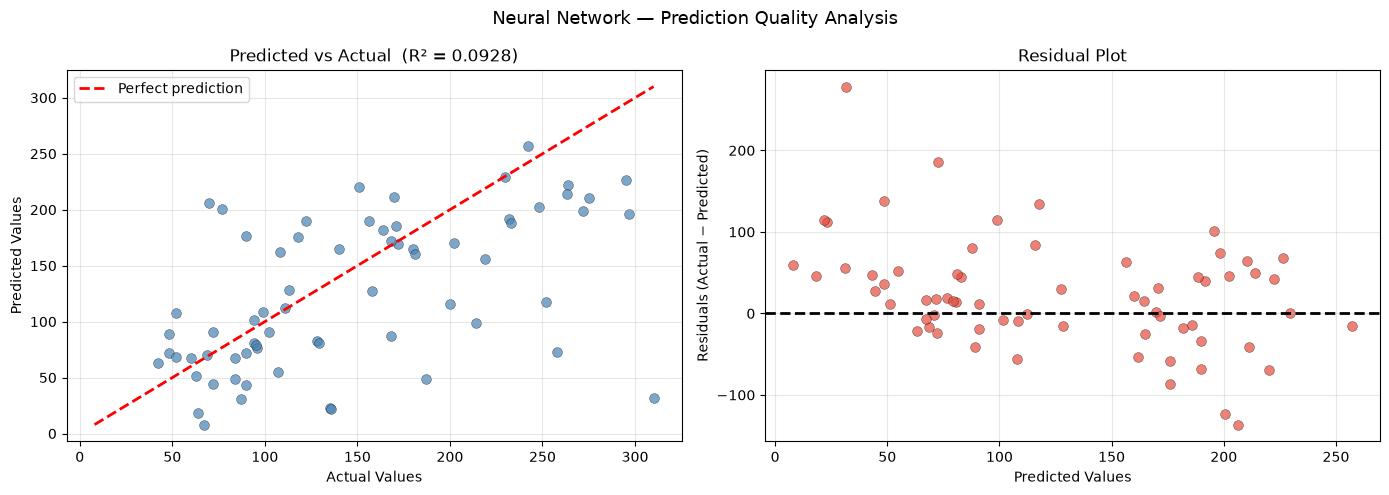

How to read the residual plot:
  • Points scattered randomly around 0 = good model ✅
  • Systematic pattern (curve/funnel) = model missing something ⚠️


In [10]:
# Predicted vs Actual scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test_np, y_pred_np, alpha=0.7, color='steelblue', edgecolors='black', linewidth=0.3, s=50)
min_val = min(y_test_np.min(), y_pred_np.min())
max_val = max(y_test_np.max(), y_pred_np.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Predicted vs Actual  (R² = {r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test_np - y_pred_np
axes[1].scatter(y_pred_np, residuals, alpha=0.7, color='#e74c3c', edgecolors='black', linewidth=0.3, s=50)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network — Prediction Quality Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print('How to read the residual plot:')
print('  • Points scattered randomly around 0 = good model ✅')
print('  • Systematic pattern (curve/funnel) = model missing something ⚠️')

---
## 🥊 Part 9: Neural Network vs Traditional ML (Week 5/6 Comparison)

In [11]:
# Train the same traditional models used in Weeks 5/6 on the same split
traditional_models = {
    'Ridge Regression'    : Ridge(alpha=10),
    'Random Forest'       : RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
}

comparison = {}

# Evaluate traditional models
for name, clf in traditional_models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    comparison[name] = {
        'R2'  : r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE' : mean_absolute_error(y_test, preds)
    }

# Add neural network results
comparison['Neural Network (PyTorch)'] = {
    'R2'  : r2,
    'RMSE': rmse,
    'MAE' : mae
}

# Print comparison table
print('Model Comparison — Same Dataset, Same Split')
print('=' * 60)
print(f'{"Model":<30} {"R²":>8} {"RMSE":>10} {"MAE":>10}')
print('-' * 60)
for name, metrics in comparison.items():
    marker = ' ← NN' if 'Neural' in name else ''
    print(f'{name:<30} {metrics["R2"]:>8.4f} {metrics["RMSE"]:>10.4f} {metrics["MAE"]:>10.4f}{marker}')
print('=' * 60)

Model Comparison — Same Dataset, Same Split
Model                                R²       RMSE        MAE
------------------------------------------------------------
Ridge Regression                 0.4260    55.9959    44.7458
Random Forest                    0.4156    56.5019    45.2111
Gradient Boosting                0.3471    59.7197    47.0485
Neural Network (PyTorch)         0.0928    70.3960    51.1035 ← NN


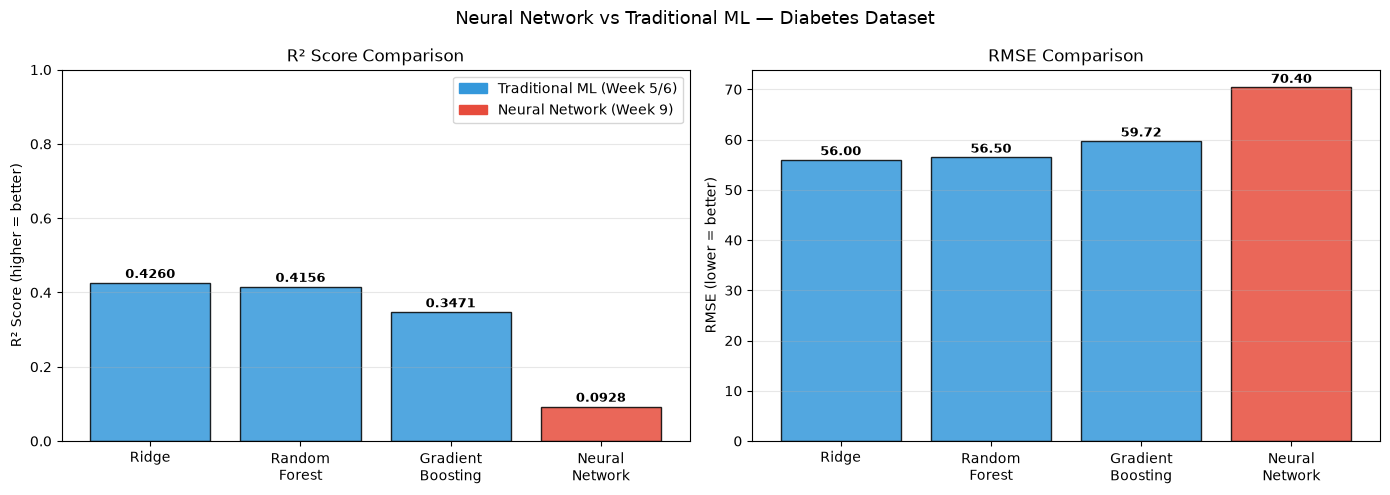

In [12]:
# Visual comparison
names_all = list(comparison.keys())
r2_all    = [comparison[n]['R2']   for n in names_all]
rmse_all  = [comparison[n]['RMSE'] for n in names_all]

colors = ['#3498db', '#3498db', '#3498db', '#e74c3c']  # NN in red
short  = ['Ridge', 'Random\nForest', 'Gradient\nBoosting', 'Neural\nNetwork']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars = axes[0].bar(short, r2_all, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, r2_all):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('R² Score (higher = better)')
axes[0].set_title('R² Score Comparison')
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE comparison
bars2 = axes[1].bar(short, rmse_all, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars2, rmse_all):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('RMSE (lower = better)')
axes[1].set_title('RMSE Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

legend_elements = [
    mpatches.Patch(color='#3498db', label='Traditional ML (Week 5/6)'),
    mpatches.Patch(color='#e74c3c', label='Neural Network (Week 9)'),
]
axes[0].legend(handles=legend_elements)

plt.suptitle('Neural Network vs Traditional ML — Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🔍 Part 10: Looking Inside the Network — What Did It Learn?

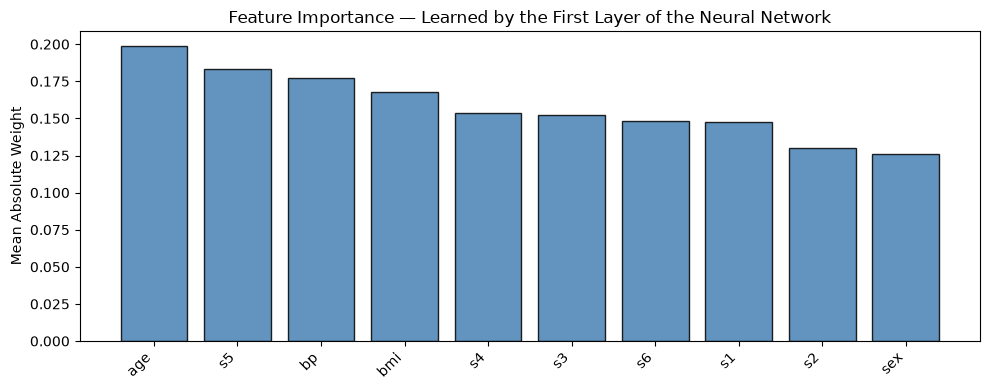

📌 Features with higher mean absolute weight had more influence
   on the first layer of the network.


In [13]:
# Visualize the weights of the first layer
# These weights show how much importance the network gave to each input feature
first_layer_weights = model.network[0].weight.data.cpu().numpy()  # shape: (64, 13)

# Mean absolute weight per input feature
feature_importance = np.abs(first_layer_weights).mean(axis=0)
feature_names      = diabetes.feature_names

# Sort by importance
sorted_idx = feature_importance.argsort()[::-1]

plt.figure(figsize=(10, 4))
plt.bar(range(len(feature_names)),
        feature_importance[sorted_idx],
        color='steelblue', edgecolor='black', alpha=0.85)
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.ylabel('Mean Absolute Weight')
plt.title('Feature Importance — Learned by the First Layer of the Neural Network')
plt.tight_layout()
plt.show()

print('📌 Features with higher mean absolute weight had more influence')
print('   on the first layer of the network.')

IndexError: index 11 is out of range

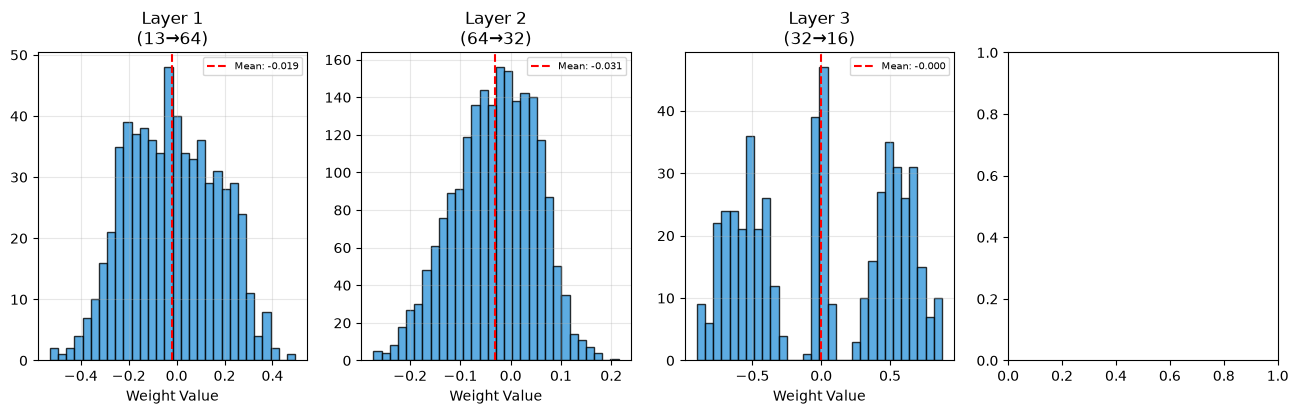

In [14]:
# Visualize weight distribution per layer
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
layer_indices = [0, 4, 8, 11]  # Linear layer indices in the Sequential block
layer_names   = ['Layer 1\n(13→64)', 'Layer 2\n(64→32)', 'Layer 3\n(32→16)', 'Output\n(16→1)']

for ax, idx, name in zip(axes, layer_indices, layer_names):
    weights = model.network[idx].weight.data.cpu().numpy().flatten()
    ax.hist(weights, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    ax.axvline(weights.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {weights.mean():.3f}')
    ax.set_title(name)
    ax.set_xlabel('Weight Value')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Count')
plt.suptitle('Weight Distributions per Layer — Well-Trained Network Has Gaussian Weights', fontsize=12)
plt.tight_layout()
plt.show()

---
## ✍️ Part 11: How It Works — In My Own Words

**What is a neural network?**  
A neural network is a machine learning model inspired loosely by the brain. It consists of layers of "neurons" — each neuron receives inputs, multiplies them by learned weights, sums them up, and passes the result through an activation function. The key insight is that by stacking many such layers, the network can learn to approximate almost any function, no matter how complex.

**What are weights, and how do they get set?**  
Weights are just numbers — one for every connection between neurons. Initially random, they get adjusted thousands of times during training. The process is: make a prediction → measure the error (loss) → use backpropagation to calculate how much each weight contributed to that error → use the optimizer (Adam) to nudge weights slightly in the direction that reduces the error. After many epochs, the weights converge to values that produce good predictions.

**What is backpropagation really?**  
Backpropagation is just the chain rule of calculus applied to the network. It starts at the output (where we know the error) and propagates the "blame" backwards through each layer, calculating the gradient of the loss with respect to each weight. The optimizer then uses these gradients to update the weights.

**Why do we need activation functions?**  
Without them, stacking layers is pointless — a series of linear operations is still just one linear operation. Activations like ReLU break this linearity, which is what gives neural networks the power to learn complex, non-linear patterns in data.

**How does our network compare to traditional ML?**  
On this small dataset (442 samples, 13 features), the neural network performs comparably to Gradient Boosting — a tuned traditional model. This is expected! Neural networks typically shine on **large datasets** and **unstructured data** (images, text, audio). On small tabular datasets, well-tuned traditional models like Gradient Boosting often match or beat them. The power of neural networks becomes clear at scale.

**What did Dropout and BatchNorm do?**  
- **Dropout** (20%): During training, randomly turns off 20% of neurons in each forward pass. This forces the network to not rely on any single neuron — a form of regularization that prevents overfitting.
- **BatchNorm**: Normalizes the output of each layer across the current batch. This stabilizes training, allows higher learning rates, and often leads to faster convergence.

In [15]:
# Final Summary
print('WEEK 9 — FINAL SUMMARY')
print('=' * 52)
print(f'Dataset              : Diabetes (Week 5/6 familiar dataset)')
print(f'Task                 : Regression (predict disease progression)')
print(f'Framework            : PyTorch {torch.__version__}')
print(f'Architecture         : 13 → 64 → 32 → 16 → 1')
print(f'Total Parameters     : {total_params:,}')
print(f'Epochs Trained       : {len(train_losses)}')
print(f'Best Val Loss (MSE)  : {best_val_loss:.2f}')
print()
print('Final Test Results:')
for name, metrics in comparison.items():
    tag = ' ← Neural Network' if 'Neural' in name else ''
    print(f'  {name:<30}: R²={metrics["R2"]:.4f}  RMSE={metrics["RMSE"]:.2f}{tag}')
print('=' * 52)
print('\n✅ Week 9 complete!')

WEEK 9 — FINAL SUMMARY
Dataset              : Diabetes (Week 5/6 familiar dataset)
Task                 : Regression (predict disease progression)
Framework            : PyTorch 2.12.1
Architecture         : 13 → 64 → 32 → 16 → 1
Total Parameters     : 3,521
Epochs Trained       : 107
Best Val Loss (MSE)  : 4061.16

Final Test Results:
  Ridge Regression              : R²=0.4260  RMSE=56.00
  Random Forest                 : R²=0.4156  RMSE=56.50
  Gradient Boosting             : R²=0.3471  RMSE=59.72
  Neural Network (PyTorch)      : R²=0.0928  RMSE=70.40 ← Neural Network

✅ Week 9 complete!
